# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 04: Transformações dos Dados (Pré-processamento)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA _PRESENCIALMENTE_ COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br), EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                              | Local           |
|-------------------------------|---------------|-----------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Segunda-feira | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quarta-feira  | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sexta-feira   | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_04_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='cyan'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/</font>

dominio = Negócios / Objetivo = classificação da intenção de compra / Tipo de informação = inteiro e real

## <font color='green'>Preparação</font>

In [2]:
!pip install pandas scikit-learn ucimlrepo

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=468)

_X_uci = ds.data.features
_y_uci = ds.data.targets

df = pd.concat([_X_uci, _y_uci], axis='columns')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='cyan'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>

Não se pode aplicar transformações no dataset inteiro antes do treino, pois o modelo passa a ter acesso indireto a informações do conjunto durante o treinamento, o que pode gerar resultados incoerentes.

### <font color='cyan'>Q2: Utilizando a função `train_test_split` biblioteca `scikit-learn`, divida as variáveis independentes (`X`) e a variável alvo (`y`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [6]:
from sklearn.model_selection import train_test_split

X = ds.data.features
y = ds.data.targets

xtrain, xtest, ytrain, ytest = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## <font color='green'>**3.2 Codificação de Atributos Categóricos**</font>

### <font color='cyan'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_train`).</font>

In [ ]:
print(xtrain.dtypes)
print(xtrain[['Month', 'VisitorType', 'Weekend']].head())

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
dtype: object
      Month        VisitorType  Weekend
1785    Mar  Returning_Visitor    False
10407   Nov  Returning_Visitor    False
286     Mar  Returning_Visitor    False
6520    Sep        New_Visitor    False
12251   Nov        New_Visitor     True


### <font color='cyan'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras originais.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [ ]:
xtrain['VisitorType'].sample(10, random_state=42)

,VisitorType
5258,Returning_Visitor
8368,Other
5564,Returning_Visitor
10481,Returning_Visitor
4570,Returning_Visitor
4815,Returning_Visitor
8558,Returning_Visitor
5247,Returning_Visitor
7681,Returning_Visitor
10353,New_Visitor


### <font color='cyan'>Q5: Aplique a técnica de `One-Hot Encoding` na variável escolhida utilizando a biblioteca scikit-learn.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='cyan'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

xtrain_visitor = encoder.fit_transform(xtrain[['VisitorType']])
xtest_visitor = encoder.transform(xtest[['VisitorType']])

### <font color='cyan'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='cyan'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [ ]:
i = xtrain['VisitorType'].sample(10, random_state=42).index
amostras1 = xtrain.loc[i, ['VisitorType']]
amostrast = encoder.transform(amostras1)

dft = pd.DataFrame(
    amostrast,
    columns=encoder.get_feature_names_out(['VisitorType']),
    index=i
)

print(dft)

       VisitorType_New_Visitor  VisitorType_Other  \
5258                       0.0                0.0   
8368                       0.0                1.0   
5564                       0.0                0.0   
10481                      0.0                0.0   
4570                       0.0                0.0   
4815                       0.0                0.0   
8558                       0.0                0.0   
5247                       0.0                0.0   
7681                       0.0                0.0   
10353                      1.0                0.0   

       VisitorType_Returning_Visitor  
5258                             1.0  
8368                             0.0  
5564                             1.0  
10481                            1.0  
4570                             1.0  
4815                             1.0  
8558                             1.0  
5247                             1.0  
7681                             1.0  
10353                     

## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='cyan'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

isso se da ao fato de kNN calcular a proximidade entre as amostras usando medidas como a chamada distância euclidiana. Em atributos numéricos que estão em escalas mais diferentes, a variável com valores maiores acaba influenciando muito mais o cálculo da distância do que as outras, oque atrapalha na precisão dos dados

### <font color='cyan'>Q8: Selecione uma coluna numérica contínua de `X_train`. Escreva o nome da característica selecionada abaixo.</font>

BounceRates, uma variável numérica contínua

### <font color='cyan'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [ ]:
coluna = xtrain['BounceRates']

print("respectivamente")
print(coluna.mean())
print(coluna.median())
print(coluna.std())
print(coluna.min())
print(coluna.max())

respectivamente
0.021658936616484187
0.002961061
0.04746854902518662
0.0
0.2


### <font color='cyan'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

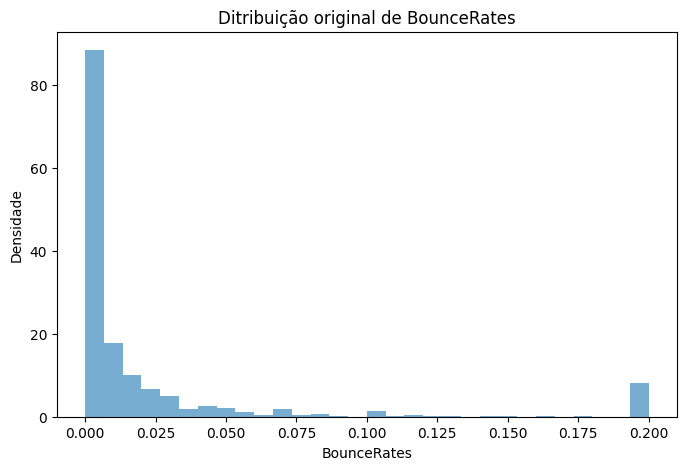

In [ ]:
coluna = xtrain['BounceRates']

plt.figure(figsize=(8, 5))
coluna.plot(kind='hist', bins=30, density=True, alpha=0.6)

plt.title('Ditribuição original de BounceRates')
plt.xlabel('BounceRates')
plt.ylabel('Densidade')
plt.show()

### <font color='cyan'>Q11: Aplique o Escalonamento nesta variável. Você pode escolher entre a Padronização (`StandardScaler`) ou a Normalização (`MinMaxScaler`), ambas da biblioteca scikit-learn.</font>

- #### <font color='cyan'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_train` e `X_test`) pelos valores escalonados.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
xtrain[['BounceRates']] = scaler.fit_transform(xtrain[['BounceRates']])
xtest[['BounceRates']] = scaler.transform(xtest[['BounceRates']])
print(xtrain[['BounceRates']].head())
print(xtest[['BounceRates']].head())

       BounceRates
1785      0.071429
10407     0.012346
286       1.000000
6520      0.000000
12251     0.200000
       BounceRates
8916      0.021739
772       0.010989
12250     0.003439
7793      0.041667
6601      0.033159


### <font color='cyan'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [ ]:
coluna = xtrain['BounceRates']

print("respectivamente")
print(coluna.mean())
print(coluna.median())
print(coluna.std())
print(coluna.min())
print(coluna.max())

respectivamente
0.10829468308242093
0.014805304999999998
0.23734274512592765
0.0
1.0


### <font color='cyan'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

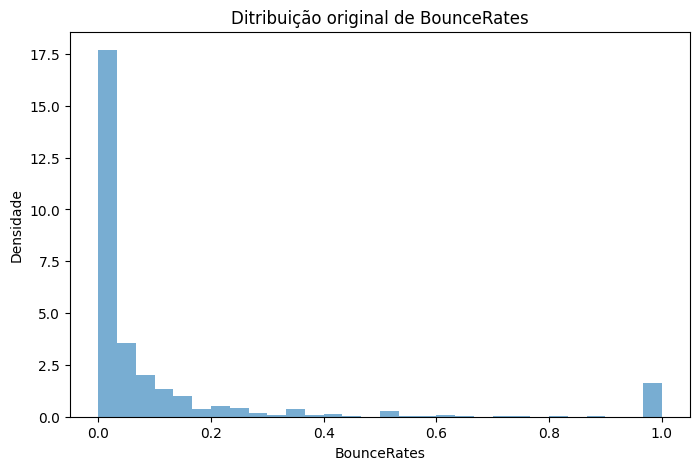

In [ ]:
coluna = xtrain['BounceRates']

plt.figure(figsize=(8, 5))
coluna.plot(kind='hist', bins=30, density=True, alpha=0.6)

plt.title('Ditribuição original de BounceRates')
plt.xlabel('BounceRates')
plt.ylabel('Densidade')
plt.show()

### <font color='cyan'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='cyan'>O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='cyan'>O que aconteceu com a escala do eixo X e com o formato da curva no gráfico?</font>

Após o escalonamento, os valores mínimo e máximo da variável passaram a ficar no intervalo 0 e 1. Com isso, a média e o desvio padrão também mudaram de valor, porque toda a coluna foi reescalada para uma nova faixa. No eixo X, antes os valores estavam entre 0 e 0,20, e então passaram a variar entre 0 e 1.O formato geral da distribuição não mudou, a curva continuou concentrando muitos valores próximos de zero.

## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='cyan'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='cyan'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

In [25]:
xtrain['Total_Abandon'] = xtrain['BounceRates'] + xtrain['ExitRates']
xtest['Total_Abandon'] = xtest['BounceRates'] + xtest['ExitRates']

# A lógica dessa nova característica é reunir em um único atributo duas medidas relacionadas ao abandono da navegação

### <font color='cyan'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [24]:
xtrain['Total_Abandon'].sample(10, random_state=42)

,Total_Abandon
5258,0.150000
8368,0.005882
5564,0.046964
10481,0.019377
4570,0.011111
4815,0.055556
8558,0.110884
5247,0.004000
7681,0.015238
10353,0.120000


### <font color='cyan'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_train`).</font>
- #### <font color='cyan'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='cyan'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='cyan'>Importante: Utilize o `LabelEncoder` da biblioteca `scikit-learn` para transformar a variável alvo (`y_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

ytrain_encoded = le.fit_transform(ytrain.values.ravel())

c = xtrain['Total_Abandon'].corr(pd.Series(ytrain_encoded))

print(c)

0.01005404945445047


## <font color='green'>**3.5 Extração / Seleção de Atributos**</font>

### <font color='cyan'>Q18: Qual a principal diferença conceitual entre Extração de Atributos (ex: `Principal Component Analysis`) e Seleção de Atributos (ex: `Variance Threshold`)? Explique.</font>

A seleção de atributos escolhe apenas as variáveis originais mais importantes do dataset, removendo as menos úteis, mas sem mudar sua forma. Já a extração de atributos cria novas variáveis a partir da combinação das originais. Assim, métodos como o Variance Threshold apenas selecionam atributos, enquanto o PCA transforma os dados em novos componentes.

### <font color='cyan'>Q19: Aplique a técnica de Análise de Componentes Principais (PCA) em todas as variáveis numéricas escalonadas.</font>

- #### <font color='cyan'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis) e ajuste-o aos dados de treinamento.</font>
- #### <font color='cyan'>b) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='cyan'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='cyan'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='cyan'>c) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

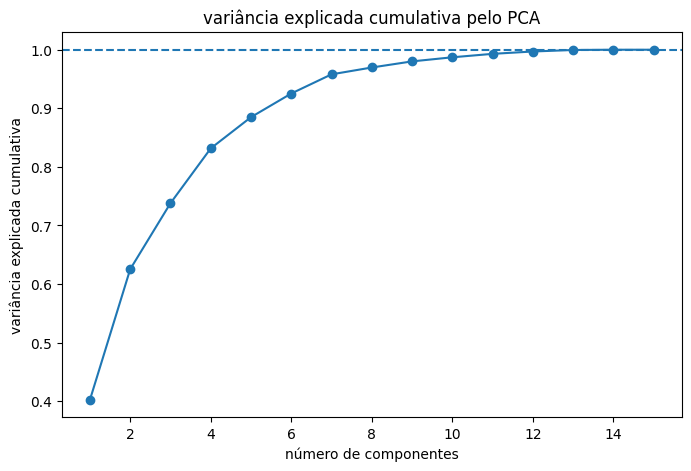

13


In [22]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

cn = xtrain.select_dtypes(include=['int64', 'float64']).columns

xtrain_num = xtrain[cn].copy()
xtest_num = xtest[cn].copy()

scaler = MinMaxScaler()
xtrain_num_scaled = scaler.fit_transform(xtrain_num)
xtest_num_scaled = scaler.transform(xtest_num)

pca = PCA()
pca.fit(xtrain_num_scaled)

vc = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.scatter(range(1, len(vc) + 1), vc)
plt.plot(range(1, len(vc) + 1), vc)
plt.axhline(y=0.999, linestyle='--')
plt.xlabel('número de componentes')
plt.ylabel('variância explicada cumulativa')
plt.title('variância explicada cumulativa pelo PCA')
plt.show()

n_c = np.argmax(vc >= 0.999) + 1
print(n_c)

# Questão C
#O limiar é muito alto porque busca toda a informação presente nos dados originais,
#reduzindo a perda de variabilidade. Dessa forma, a transformação por PCA mantém o conteúdo
#informativo do conjunto de dados, o que pode ser útil quando se deseja redução de
#dimensionalidade com mínima perda de informação.


### <font color='cyan'>Q20: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='cyan'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='cyan'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='cyan'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='cyan'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

In [21]:
# a
from sklearn.decomposition import PCA

pca_final = PCA(n_components=n_c)

xtrain_pca = pca_final.fit_transform(xtrain_num_scaled)
xtest_pca = pca_final.transform(xtest_num_scaled)

print(xtrain_num_scaled.shape)
print(xtrain_pca.shape)

print(xtest_num_scaled.shape)
print(xtest_pca.shape)

# b
#Antes da transformação, o conjunto possuia o número original de atributos numéricos.
#Após o PCA, esse número foi reduzido para a quantidade mínima de componentes necessária
#para preservada variância explicada.

# c
#Os 3 principais atributos que mais influenciam são aqueles que apresentam os maiores
#valores absolutos nos pesos da primeira linha de components_ do modelo PCA. Isso
#significa que essas variáveis são as que mais contribuem para a formação da PC1,
#tendo maior importância na direção de maior variância dos dados.

(9864, 15)
(9864, 13)
(2466, 15)
(2466, 13)
